Simulated Annealing Plots

In [1]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
%load_ext autoreload
%autoreload 2

In [2]:
# Parameters
results_path = 'data/simulated_annealing/summary_2026-04-20_01-38-38.npy'
brute_force_data_directory = './data/brute_force/test/test' # use same as in cl_optimizer_experiments

In [3]:
import numpy as np

result_tensor = np.load(results_path)

In [4]:
result_tensor.shape # should be a 6-tuple: (n_problem_sizes, n_load_factors, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 2)

(19, 10, 10, 2, 8, 2)

In [5]:
loss_tensor = result_tensor[..., 1]
temp_iterations = result_tensor[0, 0, 0, 0, :, 0]

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

extract_candidate_dimension = lambda p: np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_candidates').group(1)))
extract_load_factor = lambda p: float(re.search(string=str(p.name), pattern=r'_(\d*\.\d*)_load_factor').group(1))

data_files = [p for p in Path(brute_force_data_directory).glob("*.csv") if p.is_file()]
candidate_dims = [(extract_candidate_dimension(p), extract_load_factor(p), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dim', 'load factor', 'path'])
df = df.groupby(['dim', 'load factor'])['path'].agg(list).reset_index()

In [7]:
problem_sizes = df['dim'].unique()
load_factors = df['load factor'].unique()
brute_force_data_paths = np.array(df['path'].to_list(), dtype=object).reshape(len(problem_sizes), len(load_factors), -1)

In [8]:
import pandas as pd
import numpy as np
brute_force_data = np.vectorize(pd.read_csv)(brute_force_data_paths)
loss_spaces = [[np.array([d['loss'] for d in da]) for da in data] for data in brute_force_data] # needs to be list because is inhomogeneous

In [29]:
# RAAR | Temperature Iterations
# RAAR | Problem Size N
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=3)
raars = np.array([[[[raar(avg, loss_spaces[i][j][k, :]) for avg in avg_loss]for k, avg_loss in enumerate(avg_loss_runs_per_load_factor)] for j, avg_loss_runs_per_load_factor in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])

mean_raars_per_load_factor = raars.mean(axis=(0, 2))
std_raars_per_load_factor = raars.std(axis=(0, 2))

mean_raars = raars.mean(axis=(0, 2)).mean(axis=0) # average over load factor separately
std_raars = raars.std(axis=(0, 2)).mean(axis=0)

mean_raars_per_problem_size_and_load_factor = raars.mean(axis=(2, 3))
std_raars_per_problem_size_and_load_factor = raars.std(axis=(2, 3))

mean_raars_per_problem_size = raars.mean(axis=(2, 3)).mean(axis=1) # average over load factor separately
std_raars_per_problem_size = raars.std(axis=(2, 3)).mean(axis=1)

In [30]:
# Find optimal candidates to calculate TTS*
min_losses = np.array([[s.min(axis=1) for s in spaces] for spaces in loss_spaces])
optimal_candidates_found = np.count_nonzero(loss_tensor ==  np.expand_dims(np.expand_dims(min_losses, axis=-1), axis=-1), axis=3)
p_star = optimal_candidates_found / loss_tensor.shape[-2] # probability of finding optimal candidate

In [34]:
# TTS* | Problem Size N
from metrics import min_tts
tts_min = min_tts(p_star)

avg_min_tts_per_load_factor = tts_min.mean(axis=2)
std_min_tts_per_load_factor = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=2)

avg_min_tts = tts_min.mean(axis=-1).mean(axis=1) # average over load factor separately
std_min_tts = np.nan_to_num(tts_min, posinf=0, neginf=0, nan=0).std(axis=-1).mean(axis=1)

[[[[1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   ...
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]]

  [[1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   ...
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]]

  [[1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   ...
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]]

  ...

  [[1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   ...
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]]

  [[1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   ...
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]]

  [[1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 8.]
   ...
   [1. 2. 3. ... 6. 7. 8.]
   [1. 2. 3. ... 6. 7. 

In [32]:
avg_min_tts_per_load_factor.shape

(19, 10)

0.10437517549353553 49562082.445039876
0.1724734350145491 38443325.559026405
0.204255656273698 34451302.03360277
0.045477174271712474 27511671.48787024


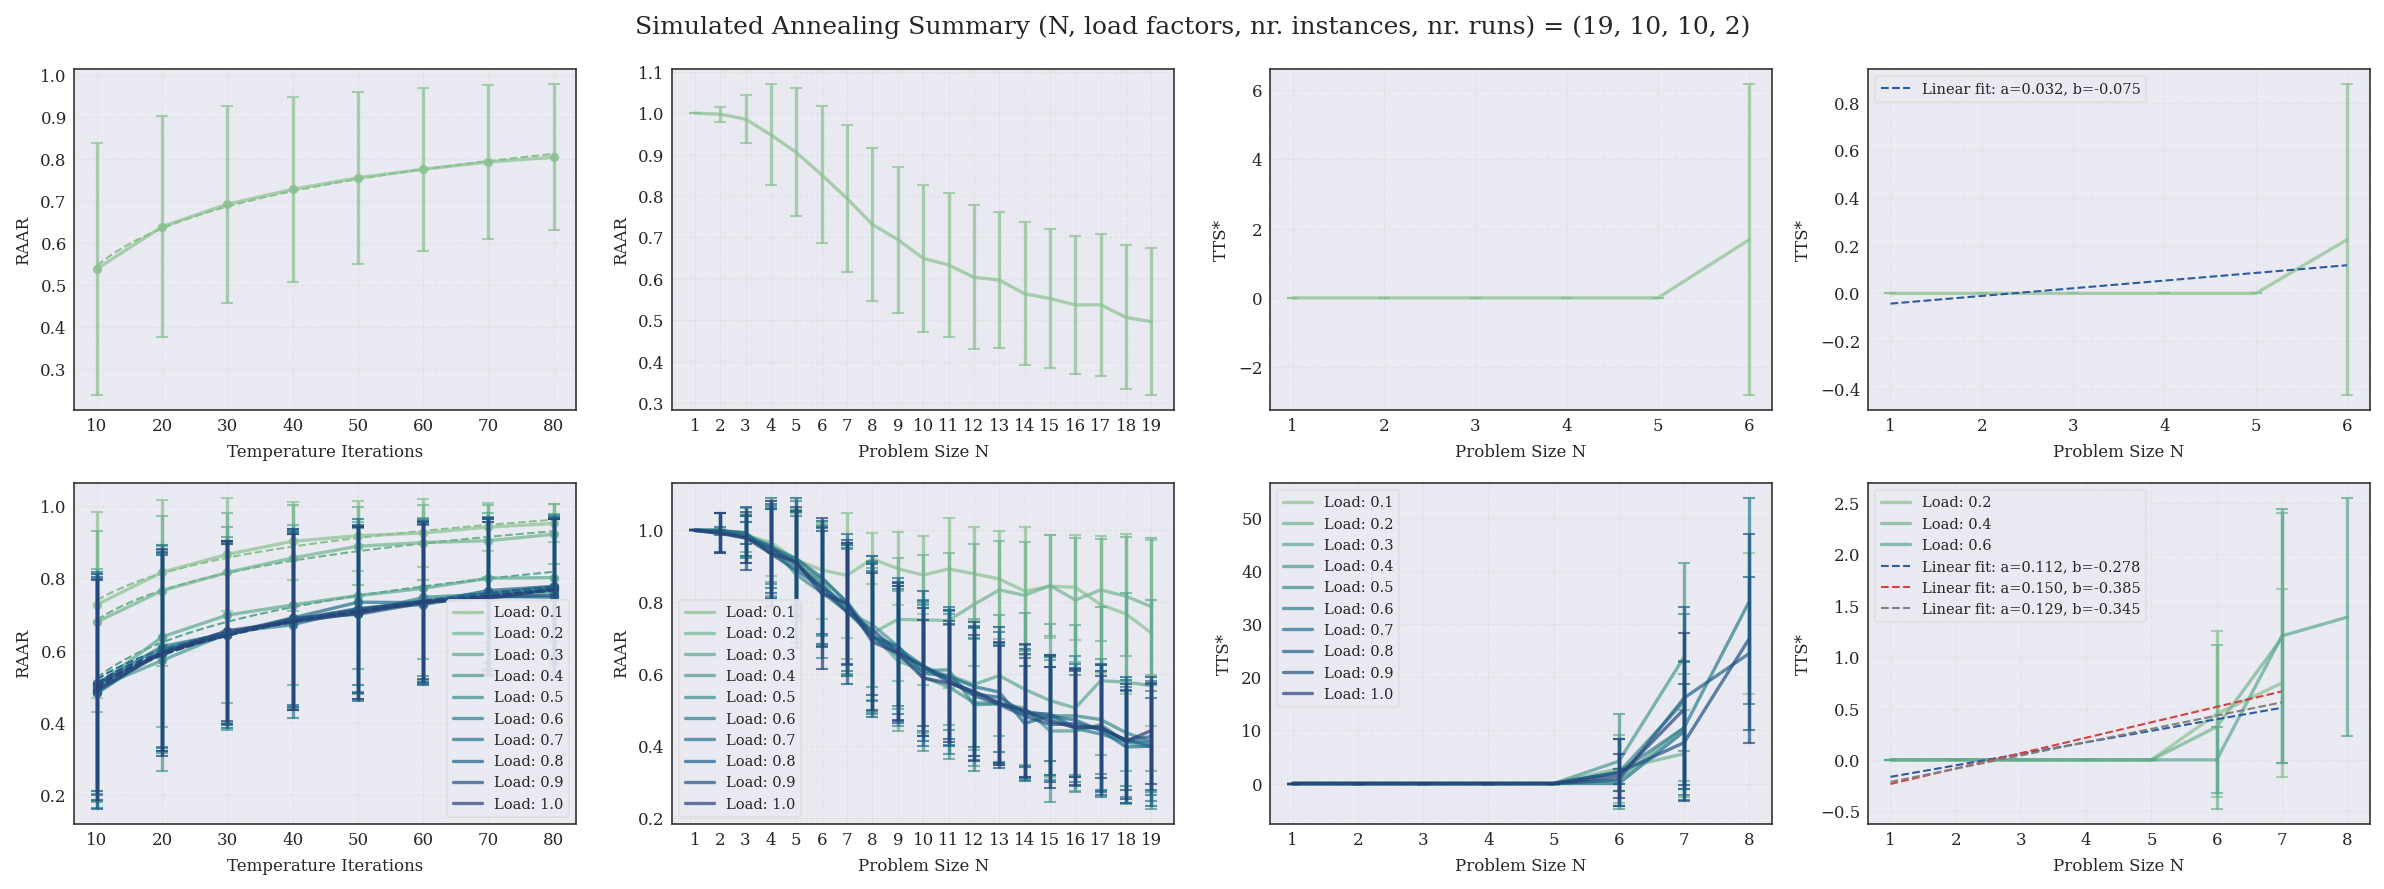

In [43]:
from plotting import plot_per_load_factor, plot_with_errorbar
from datetime import datetime
import styling
import seaborn as sns
from scipy.optimize import curve_fit

styling.set_my_style(use_latex=False)

palette = sns.color_palette("crest", len(load_factors))


fig, ax = styling.subplots(2, 4, figsize=(16, 6))

fig.suptitle(f'Simulated Annealing Summary (N, load factors, nr. instances, nr. runs) = {loss_tensor.shape[0], loss_tensor.shape[1], loss_tensor.shape[2], loss_tensor.shape[3]}')

plot_with_errorbar(ax=ax[0, 0], xs=temp_iterations, means=mean_raars, stds=std_raars, labels=('RAAR', 'Temperature Iterations'), color=palette[0], regplot=True)
plot_with_errorbar(ax=ax[0, 1], xs=problem_sizes, means=mean_raars_per_problem_size, stds=std_raars_per_problem_size, labels=('RAAR', 'Problem Size N'), color=palette[0], set_xticks=True)
plot_with_errorbar(ax=ax[0, 2], xs=problem_sizes, means=avg_min_tts, stds=std_min_tts, labels=('TTS*', 'Problem Size N'), color=palette[0], set_xticks=True)

plot_per_load_factor(
    ax=ax[1, 0],
    xs=temp_iterations,
    means=mean_raars_per_load_factor,
    stds=std_raars_per_load_factor,
    load_factors=load_factors,
    labels=("RAAR", 'Temperature Iterations'),
    palette=palette,
    regplot=True
)
plot_per_load_factor(
    ax=ax[1, 1],
    xs=problem_sizes,
    means=mean_raars_per_problem_size_and_load_factor.T,
    stds=std_raars_per_problem_size_and_load_factor.T,
    load_factors=load_factors,
    labels=("RAAR", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)
plot_per_load_factor(
    ax=ax[1, 2],
    xs=problem_sizes,
    means=avg_min_tts_per_load_factor.T,
    stds=std_min_tts_per_load_factor.T,
    load_factors=load_factors,
    labels=("TTS*", 'Problem Size N'),
    palette=palette,
    set_xticks=True,
)
mean_log_min_tts_selected_load_factors = avg_min_tts_per_load_factor.T[1::3, :].copy().clip(min=1)
std_log_min_tts_selected_load_factors = std_min_tts_per_load_factor.T[1::3, :].copy().clip(min=1)
mean_log_min_tts_selected_load_factors = np.log10(mean_log_min_tts_selected_load_factors)
std_log_min_tts_selected_load_factors = np.log10(std_log_min_tts_selected_load_factors)
plot_per_load_factor(
    ax=ax[1, 3],
    xs=problem_sizes,
    means=mean_log_min_tts_selected_load_factors,
    stds=std_log_min_tts_selected_load_factors,
    load_factors=load_factors[1::2],
    labels=("TTS*", 'Problem Size N'),
    palette=palette,
)


def linear_model(x, a, b):
    return a * x + b

def log_model(x, a, b, c, d, n):
    arg = b * x + c
    arg = np.clip(arg, 1e-10, None)  # prevent log of zero or negative
    return a * (np.log(arg) / np.log(n)) + d

mask = np.isfinite(mean_log_min_tts_selected_load_factors).all(axis=0)
means = mean_log_min_tts_selected_load_factors[:, mask]
xdata = problem_sizes[mask]

for ydata in means:
    popt_linear, pcov_linear = curve_fit(f=linear_model, xdata=xdata, ydata=ydata, nan_policy='omit')
    popt_log, pcov_log = curve_fit(f=log_model, xdata=xdata, ydata=ydata, bounds=(
        [-np.inf, 1e-6, -np.inf, -np.inf, 1.01],
        [ np.inf,  np.inf,  np.inf,  np.inf, np.inf]
    ),
    nan_policy='omit',
    maxfev=10000, p0=[1, 1, 1, 1, 10])

    perr_linear = np.mean(np.sqrt(np.diag(pcov_linear)))
    perr_log = np.mean(np.sqrt(np.diag(pcov_log)))

    print(perr_linear, perr_log)

    if perr_linear < perr_log:
        ax[1, 3].plot(xdata, linear_model(xdata, *popt_linear), label='Linear fit: a=%5.3f, b=%5.3f' % tuple(popt_linear), linestyle='dashed')
    else:
        ax[1, 3].plot(xdata, log_model(xdata, *popt_log), label='Log fit: a=%5.3f, b=%5.3f, c=%5.3f, d=%5.3f, n=%5.3f' % tuple(popt_log), linestyle='dashed')

ax[1, 3].legend()


mask = np.isfinite(avg_min_tts)
mean = np.log10(avg_min_tts.clip(min=1))[mask]
std = np.log10(std_min_tts.T.clip(min=1))[mask]
xs = problem_sizes[mask]
plot_with_errorbar(ax=ax[0, 3], xs=xs, means=mean, stds=std, labels=('TTS*', 'Problem Size N'), color=palette[0])

popt_linear, pcov_linear = curve_fit(f=linear_model, xdata=xs, ydata=mean, nan_policy='omit')
popt_log, pcov_log = curve_fit(f=log_model, xdata=xs, ydata=mean, bounds=(
    [-np.inf, 1e-6, -np.inf, -np.inf, 1.01],
    [ np.inf,  np.inf,  np.inf,  np.inf, np.inf]
),
nan_policy='omit',
maxfev=10000, p0=[1, 1, 1, 1, 10])

perr_linear = np.mean(np.sqrt(np.diag(pcov_linear)))
perr_log = np.mean(np.sqrt(np.diag(pcov_log)))

print(perr_linear, perr_log)

if perr_linear < perr_log:
    ax[0, 3].plot(xs, linear_model(xs, *popt_linear), label='Linear fit: a=%5.3f, b=%5.3f' % tuple(popt_linear), linestyle='dashed')
else:
    ax[0, 3].plot(xs, log_model(xs, *popt_log), label='Log fit: a=%5.3f, b=%5.3f, c=%5.3f, d=%5.3f, n=%5.3f' % tuple(popt_log), linestyle='dashed')

ax[0, 3].legend()

plt.tight_layout()
plt.savefig(f'./plots/simulated_annealing_performance_summary_{datetime.now().strftime("%Y%m%d-%H%M%S")}.png')